In [201]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [202]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ninzaami/loan-predication")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'loan-predication' dataset.
Path to dataset files: /kaggle/input/loan-predication


In [203]:
import os

df=pd.read_csv(os.path.join(path,'train_u6lujuX_CVtuZ9i (1).csv'))

In [204]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [205]:
df.shape

(614, 13)

In [206]:
df.duplicated().sum()

np.int64(0)

In [207]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [208]:
cat_cols=[i for i in df.columns if df[i].dtypes=='O']
cat_cols

['Loan_ID',
 'Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'Property_Area',
 'Loan_Status']

In [209]:
cat_cols.remove('Loan_ID')

In [210]:
for i in cat_cols:
  print(i)
  print(df[i].unique())
  print("*"*20)
  print()

Gender
['Male' 'Female' nan]
********************

Married
['No' 'Yes' nan]
********************

Dependents
['0' '1' '2' '3+' nan]
********************

Education
['Graduate' 'Not Graduate']
********************

Self_Employed
['No' 'Yes' nan]
********************

Property_Area
['Urban' 'Rural' 'Semiurban']
********************

Loan_Status
['Y' 'N']
********************



In [211]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [212]:
df['Credit_History'].median()

1.0

In [213]:
df.columns=df.columns.str.lower().str.strip()

In [214]:
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])
df['married'] = df['married'].fillna(df['married'].mode()[0])
df['dependents'] = df['dependents'].fillna(df['dependents'].mode()[0])
df['self_employed'] = df['self_employed'].fillna(df['self_employed'].mode()[0])

In [215]:
df['loanamount'] = df['loanamount'].fillna(df['loanamount'].median())

df['loan_amount_term'] = df['loan_amount_term'].fillna(
    df['loan_amount_term'].mode()[0]
)

df['credit_history'] = df['credit_history'].fillna(
    df['credit_history'].mode()[0]
)

In [216]:
df.isnull().sum()

,0
loan_id,0
gender,0
married,0
dependents,0
education,0
self_employed,0
applicantincome,0
coapplicantincome,0
loanamount,0
loan_amount_term,0


loan_status
Y    422
N    192
Name: count, dtype: int64



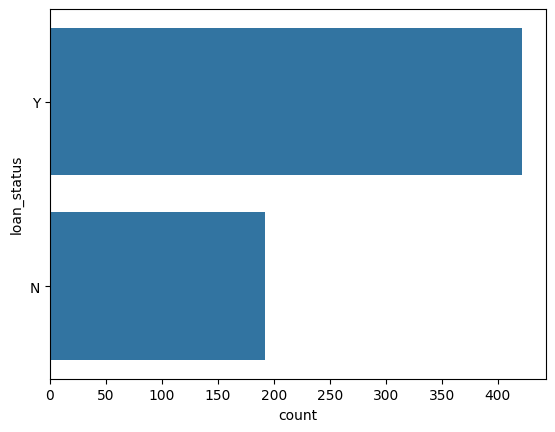

In [217]:
print(df['loan_status'].value_counts())
print()

sns.countplot(df['loan_status'])
plt.show()

In [218]:
df['dependents'].unique()

array(['0', '1', '2', '3+'], dtype=object)

In [219]:
df['dependents']=df['dependents'].str.replace('3+','3')

In [220]:
df['dependents'].unique()

array(['0', '1', '2', '3'], dtype=object)

In [221]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   loan_id            614 non-null    object 
 1   gender             614 non-null    object 
 2   married            614 non-null    object 
 3   dependents         614 non-null    object 
 4   education          614 non-null    object 
 5   self_employed      614 non-null    object 
 6   applicantincome    614 non-null    int64  
 7   coapplicantincome  614 non-null    float64
 8   loanamount         614 non-null    float64
 9   loan_amount_term   614 non-null    float64
 10  credit_history     614 non-null    float64
 11  property_area      614 non-null    object 
 12  loan_status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [222]:
df.drop('loan_id',axis=1,inplace=True)

In [223]:
df.duplicated().sum()

np.int64(0)

In [224]:
df['gender']=df['gender'].map({
    "Female":1,
    "Male":0
})

df['married']=df['married'].map({
    "Yes":1,
    "No":0
})

df['education']=df['education'].map({
    "Graduate":1,
    "Not Graduate":0
})

df['self_employed']=df['self_employed'].map({
    "Yes":1,
    "No":0
})

In [225]:
df['loan_status']=df['loan_status'].map({
    "Y":1,
    "N":0
})

In [226]:
X=df.drop('loan_status',axis=1)
y=df['loan_status']

In [227]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [228]:
num_cols=[i for i in df.columns if df[i].dtypes!='O']
num_cols

['gender',
 'married',
 'education',
 'self_employed',
 'applicantincome',
 'coapplicantincome',
 'loanamount',
 'loan_amount_term',
 'credit_history',
 'loan_status']

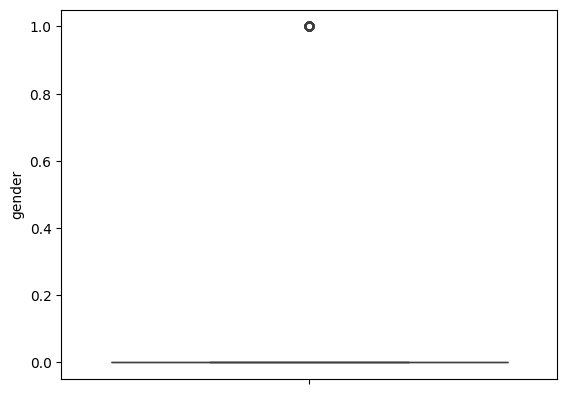

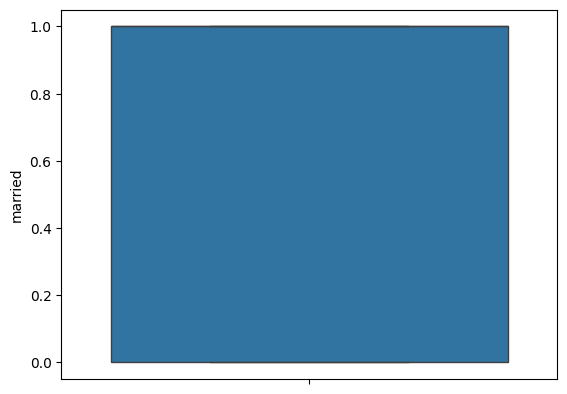

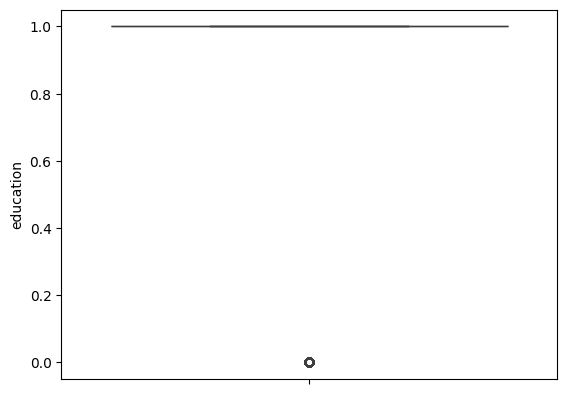

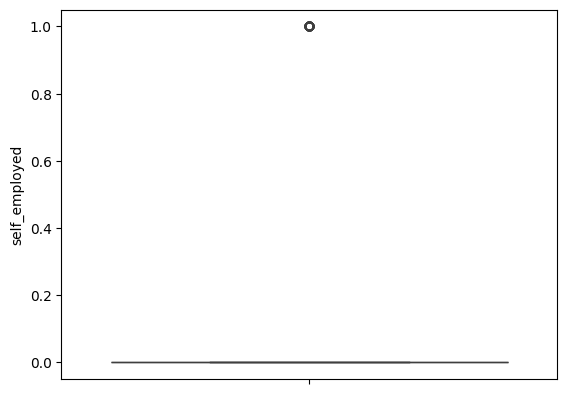

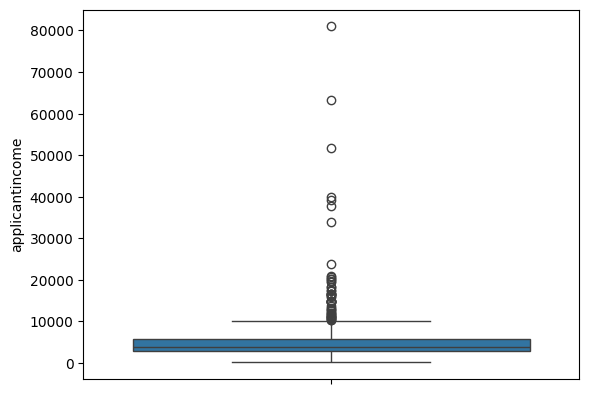

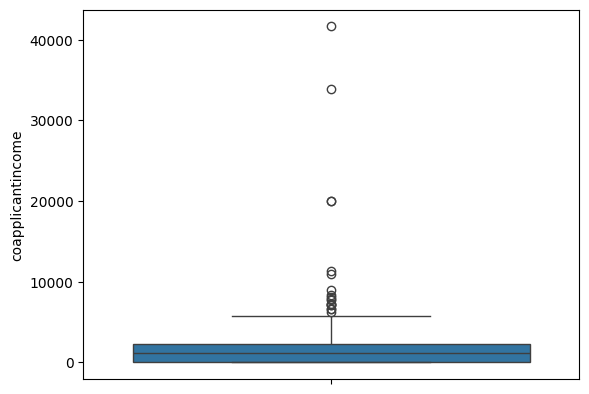

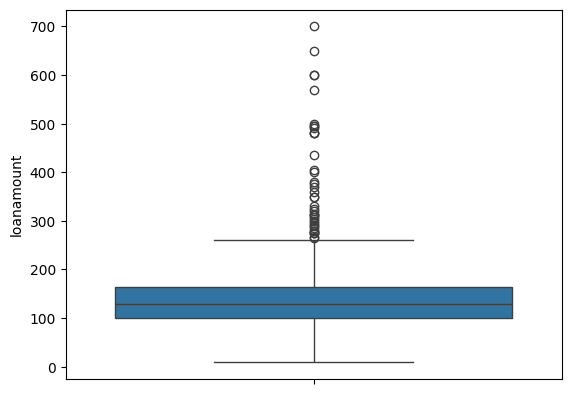

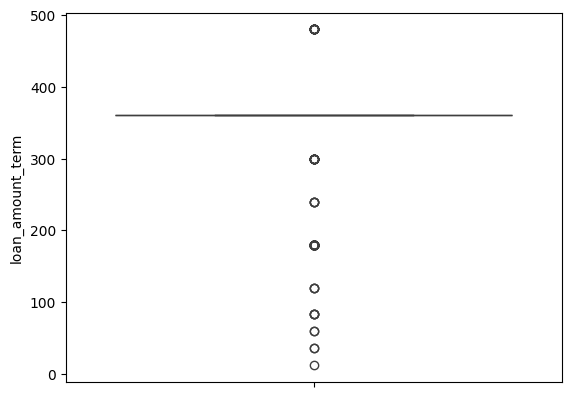

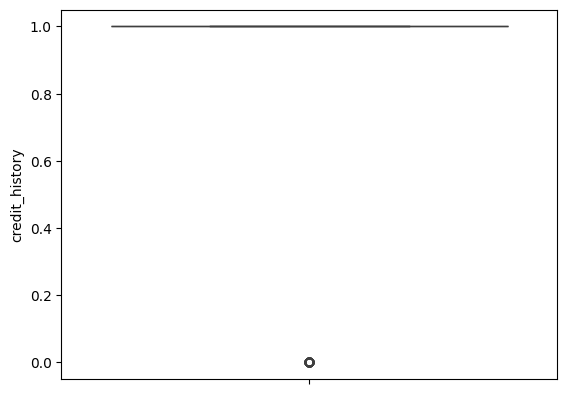

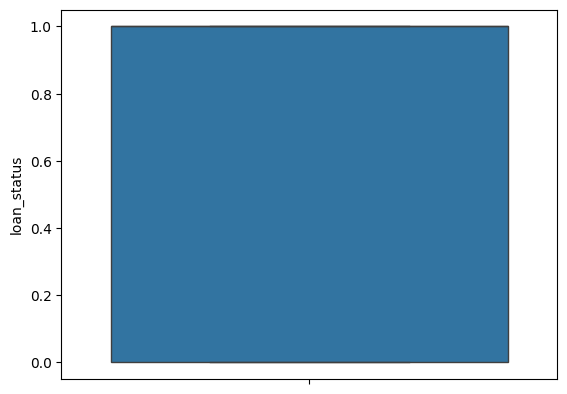

In [229]:
for i in num_cols:
  sns.boxplot(df[i])
  plt.show()

In [230]:
df['loan_amount_term'].unique()

array([360., 120., 240., 180.,  60., 300., 480.,  36.,  84.,  12.])

In [231]:
df['loanamount'].unique()

array([128.,  66., 120., 141., 267.,  95., 158., 168., 349.,  70., 109.,
       200., 114.,  17., 125., 100.,  76., 133., 115., 104., 315., 116.,
       112., 151., 191., 122., 110.,  35., 201.,  74., 106., 320., 144.,
       184.,  80.,  47.,  75., 134.,  96.,  88.,  44., 286.,  97., 135.,
       180.,  99., 165., 258., 126., 312., 136., 172.,  81., 187., 113.,
       176., 130., 111., 167., 265.,  50., 210., 175., 131., 188.,  25.,
       137., 160., 225., 216.,  94., 139., 152., 118., 185., 154.,  85.,
       259., 194.,  93., 370., 182., 650., 102., 290.,  84., 242., 129.,
        30., 244., 600., 255.,  98., 275., 121.,  63., 700.,  87., 101.,
       495.,  67.,  73., 260., 108.,  58.,  48., 164., 170.,  83.,  90.,
       166., 124.,  55.,  59., 127., 214., 240.,  72.,  60., 138.,  42.,
       280., 140., 155., 123., 279., 192., 304., 330., 150., 207., 436.,
        78.,  54.,  89., 143., 105., 132., 480.,  56., 159., 300., 376.,
       117.,  71., 490., 173.,  46., 228., 308., 23

In [232]:
from sklearn.preprocessing import StandardScaler,FunctionTransformer,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


# skewed pipeline
skew_pipeline=Pipeline([
    ("log transformer",FunctionTransformer(np.log1p)),
    ("scaler",StandardScaler())
])

# scaling
scale_pipeline=Pipeline([
    ("scaler",StandardScaler())
])

#ohe
ohe_pipeline=Pipeline([
    ("ohe",OneHotEncoder(handle_unknown='ignore'))
])

skewed_cols=['applicantincome', 'coapplicantincome', 'loanamount']
normal_cols=['gender', 'married', 'education', 'self_employed','credit_history']
scale_cols=['dependents','loan_amount_term']
ohe_cols=['property_area']


preprocessor=ColumnTransformer([
    ("skewed",skew_pipeline,skewed_cols),
    ("scaler",scale_pipeline,scale_cols),
    ("ohe",ohe_pipeline,ohe_cols),
    ("passthrough","passthrough",normal_cols)
])

In [233]:
preprocessor

ColumnTransformer(transformers=[('skewed',
                                 Pipeline(steps=[('log transformer',
                                                  FunctionTransformer(func=<ufunc 'log1p'>)),
                                                 ('scaler', StandardScaler())]),
                                 ['applicantincome', 'coapplicantincome',
                                  'loanamount']),
                                ('scaler',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['dependents', 'loan_amount_term']),
                                ('ohe',
                                 Pipeline(steps=[('ohe',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['property_area']),
                                ('passthrough', 'passthrough',
                                 ['gender', 'married', 'education',
                                  'self_employed', 'credit_history'])])

In [234]:
X_train.shape[1]

11

In [235]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [236]:
#create ann model

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Dropout

model = Sequential([
    Dense(
        64,
        activation='relu',
        input_shape=(X_train_processed.shape[1],)
    ),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [237]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

In [238]:
from tensorflow.keras.metrics import Precision

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        Precision(name='precision'),
        'accuracy'
    ]
)

In [239]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_precision',
    patience=5,
    mode='max',
    restore_best_weights=True
)

history = model.fit(
    X_train_processed,
    y_train,
    epochs=50,
    validation_data=(X_test_processed, y_test),
    callbacks=[early_stop]
)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5947 - loss: 0.6644 - precision: 0.6816 - val_accuracy: 0.6911 - val_loss: 0.6098 - val_precision: 0.6911
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6864 - loss: 0.6201 - precision: 0.6910 - val_accuracy: 0.6911 - val_loss: 0.5853 - val_precision: 0.6911
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6864 - loss: 0.6057 - precision: 0.6871 - val_accuracy: 0.6911 - val_loss: 0.5739 - val_precision: 0.6911
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6945 - loss: 0.5853 - precision: 0.6928 - val_accuracy: 0.6911 - val_loss: 0.5653 - val_precision: 0.6911
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6945 - loss: 0.5805 - precision: 0.6936 - val_accuracy: 0.6992 - val_loss: 0.5588 - val_precision: 0.6967
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7047 - loss: 0.5656 - precision: 0.7000 - val_accuracy: 0.6911 - val_loss: 0.5495 - v

In [240]:
loss,acc,prec=model.evaluate(X_test_processed,y_test)

print(loss)
print(acc)
print(prec)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8537 - loss: 0.4188 - precision: 0.8454
0.418769508600235
0.8453608155250549
0.8536585569381714


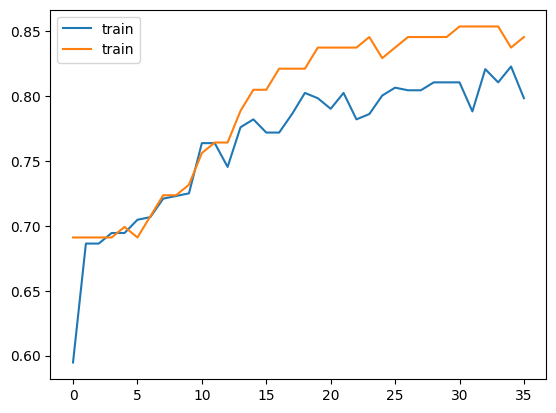

In [242]:
plt.plot(history.history['accuracy'],label='train')
plt.plot(history.history['val_accuracy'],label='train')
plt.legend()
plt.show()

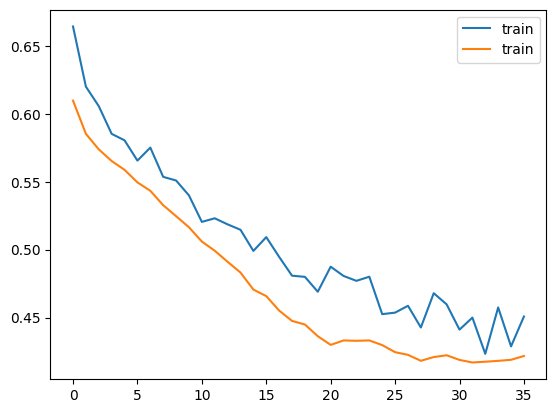

In [243]:
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='train')
plt.legend()
plt.show()

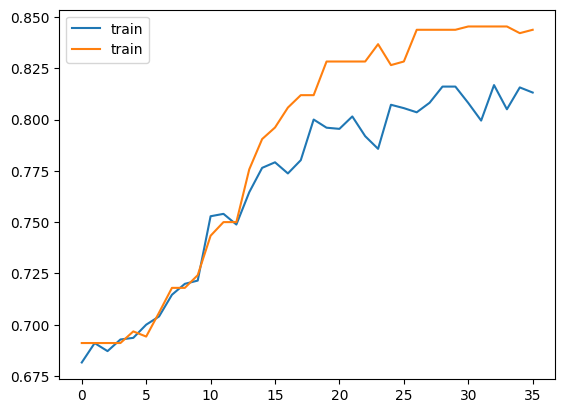

In [244]:
plt.plot(history.history['precision'],label='train')
plt.plot(history.history['val_precision'],label='train')
plt.legend()
plt.show()

In [245]:
new_data = pd.DataFrame([{
    'gender': 0,
    'married': 1,
    'dependents': 1,
    'education': 1,
    'self_employed': 0,
    'applicantincome': 5000,
    'coapplicantincome': 2000,
    'loanamount': 150,
    'loan_amount_term': 360,
    'credit_history': 1,
    'property_area': 'Semiurban'
}])

new_data

,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area
0,0,1,1,1,0,5000,2000,150,360,1,Semiurban


In [246]:
new_data_processed=preprocessor.transform(new_data)
new_data_processed

array([[0.24581631, 0.87439598, 0.29877455, 0.25020681, 0.28069139,
        0.        , 1.        , 0.        , 0.        , 1.        ,
        1.        , 0.        , 1.        ]])

In [249]:
new_data_pred = model.predict(new_data_processed)

prediction = (new_data_pred >= 0.5).astype(int)

print("Probability:", new_data_pred[0][0])
print("Prediction:", prediction[0][0])

if prediction[0][0] == 1:
    print("Loan Approved")
else:
    print("Loan Not Approved")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Probability: 0.9215674
Prediction: 1
Loan Approved
